UT-Former: Urban Construction Change Detection Using Multi-Temporal HR & Sentinel-2 Imagery (ISPRS 2025)

Team: University of Tehran — UT-Former

Team Members:

•	Mahdi Farhangi – Student ID: 810304008 – ma.farhangi@ut.ac.ir

•	Niloofar Darbandsari – Student ID: 810303032 – Niloo.Darbandsari@ut.ac.ir

University of Tehran – Faculty of Surveying & Geospatial Information Engineering

Dataset & Result:
https://drive.google.com/drive/folders/1_Io0hGr_vYqhXpPeMJf73H3fg37V7DlQ?usp=sharing

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# ============================
# Section 0) Install prerequisites
# ============================
!pip install rasterio geopandas shapely albumentations tifffile tqdm einops


# ============================
# Section 1) Connect to Google Drive
# ============================
from google.colab import drive
drive.mount('/content/drive')


# ============================
# Section 2) Dataset path setup
# ============================
dataset_root = "/content/drive/My Drive/ISPRS-Main/Urban_CD_Train_Data"

import os

print("Dataset root: ", dataset_root)
print("Folders inside:")
print(os.listdir(dataset_root))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset root:  /content/drive/My Drive/ISPRS-Main/Urban_CD_Train_Data
Folders inside:
['L15-0331E-1257N_1327_3160_13', 'L15-0357E-1223N_1429_3296_13', 'L15-0358E-1220N_1433_3310_13', 'L15-0368E-1245N_1474_3210_13', 'L15-0434E-1218N_1736_3318_13', 'L15-0457E-1135N_1831_3648_13', 'L15-0506E-1204N_2027_3374_13', 'L15-0544E-1228N_2176_3279_13', 'L15-0577E-1243N_2309_3217_13', 'L15-0586E-1127N_2345_3680_13', 'L15-0595E-1278N_2383_3079_13', 'L15-0683E-1006N_2732_4164_13', 'L15-0760E-0887N_3041_4643_13', 'L15-0924E-1108N_3699_3757_13', 'L15-1014E-1375N_4056_2688_13', 'L15-1015E-1062N_4061_3941_13', 'L15-1025E-1366N_4102_2726_13', 'L15-1049E-1370N_4196_2710_13', 'L15-1138E-1216N_4553_3325_13', 'L15-1172E-1306N_4688_2967_13', 'L15-1200E-0847N_4802_4803_13', 'L15-1203E-1203N_4815_3378_13', 'L15-1204E-1204N_4819_3372_13', 'L15-1209E-1113N_4838_3737_13', 'L15-1210E-1025N

In [3]:
# ============================
# Section 3) Import libraries and set dataset path
# ============================
import os
import rasterio
import geopandas as gpd
from rasterio.features import rasterize
from rasterio.transform import from_bounds

# Dataset root directory
DATA_ROOT = "/content/drive/My Drive/ISPRS-Main/Urban_CD_Train_Data"


# ============================
# Section 4) Define rasterization function
# ============================
def rasterize_building_mask(geojson_path, reference_tif, out_path):
    """Rasterize building polygons from GeoJSON based on reference image resolution/transform."""
    gdf = gpd.read_file(geojson_path)

    with rasterio.open(reference_tif) as src:
        meta = src.meta.copy()
        transform = src.transform
        out_shape = (src.height, src.width)

    # Handle empty file (no buildings present)
    if len(gdf) == 0:
        mask = np.zeros(out_shape, dtype="uint8")
    else:
        shapes = [(geom, 1) for geom in gdf.geometry]
        mask = rasterize(shapes, out_shape=out_shape, transform=transform, fill=0)

    meta.update({"count": 1, "dtype": "uint8"})

    # Save rasterized mask
    with rasterio.open(out_path, "w", **meta) as dst:
        dst.write(mask, 1)

    return mask


# ============================
# Section 5) Iterate over dataset locations
# ============================
import numpy as np
from tqdm import tqdm

# List all locations inside dataset
locations = sorted(os.listdir(DATA_ROOT))

for loc in tqdm(locations):
    loc_path = os.path.join(DATA_ROOT, loc)

    labels_path = os.path.join(loc_path, "Labels")
    hr_path = os.path.join(loc_path, "SN7-RGB-HR")

    # Find HR image at first time (reference transform)
    t1_hr = None
    for f in os.listdir(hr_path):
        if f.endswith(".tif") and "2018" in f or "2017" in f:
            t1_hr = os.path.join(hr_path, f)
            break

    if t1_hr is None:
        print("HR T1 not found for ", loc)
        continue

    # Find building GeoJSON files
    geos = [f for f in os.listdir(labels_path) if f.endswith(".geojson") and "Buildings" in f]

    if len(geos) != 2:
        print(" Warning:", loc, " --> Found ", geos)
        continue

    # Sort GeoJSON files by date (e.g., 2018 → T1 , 2020 → T2)
    geos_sorted = sorted(geos)

    T1_geo = os.path.join(labels_path, geos_sorted[0])
    T2_geo = os.path.join(labels_path, geos_sorted[1])

    # Output paths for masks and change map
    out_T1 = os.path.join(loc_path, "mask_T1.tif")
    out_T2 = os.path.join(loc_path, "mask_T2.tif")
    out_change = os.path.join(loc_path, "change_map.tif")

    # Rasterize T1 & T2 building masks
    mask_T1 = rasterize_building_mask(T1_geo, t1_hr, out_T1)
    mask_T2 = rasterize_building_mask(T2_geo, t1_hr, out_T2)

    # Build change map (new buildings only)
    change = ((mask_T1 == 0) & (mask_T2 == 1)).astype("uint8")

    with rasterio.open(t1_hr) as src:
        meta = src.meta.copy()
    meta.update({"count": 1, "dtype": "uint8"})

    # Save change map
    with rasterio.open(out_change, "w", **meta) as dst:
        dst.write(change, 1)

# ============================
# Section 6) Final message
# ============================
print(" Rasterization + Change Map generation completed!")

100%|██████████| 40/40 [00:45<00:00,  1.13s/it]

 Rasterization + Change Map generation completed!


In [4]:
# ============================
# Section 7) Import libraries and set dataset path
# ============================
import os
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
import numpy as np
from tqdm import tqdm

# Dataset root directory
DATA_ROOT = "/content/drive/My Drive/ISPRS-Main/Urban_CD_Train_Data"


# ============================
# Section 8) Define helper functions
# ============================
def load_hr_reference(location_path):
    """Find HR TIFF for reference size/transform."""
    hr_path = os.path.join(location_path, "SN7-RGB-HR")
    for f in os.listdir(hr_path):
        if f.endswith(".tif") and ("2018" in f or "2017" in f):
            return os.path.join(hr_path, f)
    raise FileNotFoundError("HR reference not found!")


def resample_to_hr(s2_band_path, ref_profile):
    """Resample Sentinel-2 band to match HR image resolution."""
    with rasterio.open(s2_band_path) as src:
        src_data = src.read(1)

        # Create empty destination array with HR dimensions
        dst_data = np.zeros((ref_profile["height"], ref_profile["width"]), dtype=src_data.dtype)

        # Perform reprojection and resampling
        reproject(
            source=src_data,
            destination=dst_data,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=ref_profile["transform"],
            dst_crs=ref_profile["crs"],
            resampling=Resampling.bilinear
        )

        return dst_data


def process_sentinel_folder(s2_folder, hr_ref_path, out_path):
    """Resample all 12 Sentinel-2 bands to HR resolution and stack them."""
    with rasterio.open(hr_ref_path) as ref:
        hr_profile = ref.profile

    # Collect all band files
    band_files = sorted([f for f in os.listdir(s2_folder) if f.endswith(".tiff") or f.endswith(".tif")])

    stacked = []

    # Resample each band and append to stack
    for bf in band_files:
        band_path = os.path.join(s2_folder, bf)
        resampled = resample_to_hr(band_path, hr_profile)
        stacked.append(resampled)

    # Stack into single array with shape [12, H, W]
    stacked = np.stack(stacked, axis=0)

    # Save as NumPy file
    np.save(out_path, stacked)
    return stacked


# ============================
# Section 9) Process dataset locations
# ============================
locations = sorted(os.listdir(DATA_ROOT))

for loc in tqdm(locations, desc="Resampling Sentinel"):
    loc_path = os.path.join(DATA_ROOT, loc)

    # Load HR reference image
    hr_ref = load_hr_reference(loc_path)

    # Sentinel-2 folders
    s2_root = os.path.join(loc_path, "Sentinel-2 Images")
    s2_times = sorted(os.listdir(s2_root))

    # Ensure exactly two time steps exist
    if len(s2_times) != 2:
        print(" Irregular S2 folder:", loc)
        continue

    T1_path = os.path.join(s2_root, s2_times[0])
    T2_path = os.path.join(s2_root, s2_times[1])

    # Output paths for resampled arrays
    out_T1 = os.path.join(loc_path, "sentinel_T1_4m.npy")
    out_T2 = os.path.join(loc_path, "sentinel_T2_4m.npy")

    # Process both time steps
    process_sentinel_folder(T1_path, hr_ref, out_T1)
    process_sentinel_folder(T2_path, hr_ref, out_T2)


# ============================
# Section 10) Final message
# ============================
print(" Resampling Sentinel to 4m finished successfully!")

Resampling Sentinel: 100%|██████████| 40/40 [00:58<00:00,  1.46s/it]

 Resampling Sentinel to 4m finished successfully!


In [5]:
# ============================
# Section 11) Import libraries and set paths
# ============================
import os
import numpy as np
import rasterio
from tqdm import tqdm
from pathlib import Path

# Dataset and patch output directories
DATA_ROOT = "/content/drive/My Drive/ISPRS-Main/Urban_CD_Train_Data"
PATCH_ROOT = "/content/drive/My Drive/ISPRS-Main/PATCHES"
os.makedirs(PATCH_ROOT, exist_ok=True)

# Create subfolders for patches
os.makedirs(f"{PATCH_ROOT}/X1", exist_ok=True)
os.makedirs(f"{PATCH_ROOT}/X2", exist_ok=True)
os.makedirs(f"{PATCH_ROOT}/Y", exist_ok=True)


# ============================
# Section 12) Patch settings
# ============================
PATCH_SIZE = 128   # Best patch size
STRIDE     = 128   # Stride for overlap to improve accuracy


# ============================
# Section 13) Helper functions
# ============================
def read_tiff(path):
    """Read TIFF file and return as numpy array."""
    with rasterio.open(path) as src:
        return src.read()


def patchify(img, patch_size=PATCH_SIZE, stride=STRIDE):
    """Divide [C,H,W] arrays into patches."""
    C, H, W = img.shape
    patches = []

    for y in range(0, H - patch_size + 1, stride):
        for x in range(0, W - patch_size + 1, stride):
            patch = img[:, y:y+patch_size, x:x+patch_size]
            patches.append(patch)
    return patches


# ============================
# Section 14) Patchify dataset
# ============================
locations = sorted(os.listdir(DATA_ROOT))
patch_id = 0

for loc in tqdm(locations, desc="PATCHIFY locations"):
    loc_path = f"{DATA_ROOT}/{loc}"

    # Load HR images
    hr_folder = f"{loc_path}/SN7-RGB-HR"
    hr_files = sorted([f for f in os.listdir(hr_folder) if f.endswith(".tif")])

    hr_T1 = read_tiff(f"{hr_folder}/{hr_files[0]}")
    hr_T2 = read_tiff(f"{hr_folder}/{hr_files[1]}")

    # Load Sentinel numpy stacks
    s2_T1 = np.load(f"{loc_path}/sentinel_T1_4m.npy")
    s2_T2 = np.load(f"{loc_path}/sentinel_T2_4m.npy")

    # Load Change map
    change = read_tiff(f"{loc_path}/change_map.tif")

    # Build full tensors (HR + Sentinel)
    X1 = np.concatenate([hr_T1, s2_T1], axis=0)
    X2 = np.concatenate([hr_T2, s2_T2], axis=0)
    Y  = change

    # Patchify tensors
    patches_X1 = patchify(X1, PATCH_SIZE, STRIDE)
    patches_X2 = patchify(X2, PATCH_SIZE, STRIDE)
    patches_Y  = patchify(Y , PATCH_SIZE, STRIDE)

    # Save patches
    for i in range(len(patches_X1)):
        np.save(f"{PATCH_ROOT}/X1/patch_{patch_id}.npy", patches_X1[i])
        np.save(f"{PATCH_ROOT}/X2/patch_{patch_id}.npy", patches_X2[i])
        np.save(f"{PATCH_ROOT}/Y/patch_{patch_id}.npy",  patches_Y[i])

        patch_id += 1


# ============================
# Section 15) Final message
# ============================
print(" Patchify DONE — all patches created successfully!")
print("Total patches:", patch_id)


PATCHIFY locations: 100%|██████████| 40/40 [02:29<00:00,  3.75s/it]

 Patchify DONE — all patches created successfully!
Total patches: 2426


In [6]:
# ============================
# Section 16) Import libraries and set patch root
# ============================
import os
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import albumentations as A

# Root directory for patches
PATCH_ROOT = "/content/drive/My Drive/ISPRS-Main/PATCHES"


# ============================
# Section 17) Define Change Detection Dataset
# ============================
class ChangeDetectionDataset(Dataset):
    def __init__(self, root, ids, augment=False):
        self.root = root
        self.ids = ids
        self.augment = augment

        # Define augmentation pipeline
        self.transform = A.Compose([
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),
            A.RandomRotate90(p=0.4),
            A.Affine(scale=(0.9,1.1), rotate=(-10,10), p=0.4),
            A.RandomBrightnessContrast(p=0.3),
        ], additional_targets={"image2": "image", "mask": "mask"})

    def fix_channels(self, x):
        """Ensure tensor has exactly 16 channels (pad or trim if needed)."""
        if x.shape[0] > 16:
            return x[:16]
        if x.shape[0] < 16:
            return np.concatenate([x, np.zeros((16-x.shape[0], *x.shape[1:]))], axis=0)
        return x

    def __getitem__(self, idx):
        """Load and preprocess one sample (X1, X2, Y)."""
        pid = self.ids[idx]

        # Load patches
        X1 = np.load(f"{self.root}/X1/{pid}.npy")
        X2 = np.load(f"{self.root}/X2/{pid}.npy")
        Y  = np.load(f"{self.root}/Y/{pid}.npy")

        # Fix channel dimensions
        X1 = self.fix_channels(X1)
        X2 = self.fix_channels(X2)

        # Normalize to [0,1]
        X1 = X1.astype(np.float32) / 65535.0
        X2 = X2.astype(np.float32) / 65535.0

        # Change shape from [C,H,W] → [H,W,C]
        X1, X2, Y = X1.transpose(1,2,0), X2.transpose(1,2,0), Y.transpose(1,2,0)

        # Apply augmentations if enabled
        if self.augment:
            out = self.transform(image=X1, image2=X2, mask=Y)
            X1, X2, Y = out["image"], out["image2"], out["mask"]

        # Convert back to [C,H,W]
        X1 = X1.transpose(2,0,1).copy()
        X2 = X2.transpose(2,0,1).copy()
        Y  = Y.transpose(2,0,1).copy()

        # Return tensors
        return (
            torch.tensor(X1, dtype=torch.float32),
            torch.tensor(X2, dtype=torch.float32),
            torch.tensor(Y,  dtype=torch.float32)
        )

    def __len__(self):
        """Return dataset length."""
        return len(self.ids)


In [7]:
# ============================
# Section 18) Import libraries
# ============================
import os
from sklearn.model_selection import train_test_split

# ============================
# Section 19) Prepare patch IDs
# ============================
# List all patch IDs from X1 folder
all_ids = [f.replace(".npy", "") for f in os.listdir(f"{PATCH_ROOT}/X1")]

# ============================
# Section 20) Train/Validation split
# ============================
train_ids, val_ids = train_test_split(all_ids, test_size=0.2, random_state=42)

# ============================
# Section 21) Build datasets
# ============================
train_dataset = ChangeDetectionDataset(PATCH_ROOT, train_ids, augment=True)
val_dataset   = ChangeDetectionDataset(PATCH_ROOT, val_ids, augment=False)

# ============================
# Section 22) Create DataLoaders
# ============================
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=4, shuffle=False, num_workers=2)

# ============================
# Section 23) Final check
# ============================
print("Train patches:", len(train_dataset))
print("Validation patches:", len(val_dataset))


Train patches: 1940
Validation patches: 486


# **UT-Former**

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipython-input-1014797695.py:156: UserWarning: Argument(s) 'max_holes, max_height, max_width' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=4, max_height=32, max_width=32, p=0.2),


 Training started with OneCycleLR…


100%|██████████| 485/485 [00:47<00:00, 10.28it/s]


Epoch 001 | LR=0.000004 | TrainLoss=1.7681 | ValLoss=1.7291 | IoU=0.0001 | F1=0.0003
 BEST MODEL SAVED


100%|██████████| 485/485 [00:28<00:00, 16.89it/s]


...

Epoch 128 | LR=0.000000 | TrainLoss=0.9407 | ValLoss=0.8998 | IoU=0.1570 | F1=0.2423


100%|██████████| 485/485 [00:31<00:00, 15.52it/s]


Epoch 129 | LR=0.000000 | TrainLoss=0.9428 | ValLoss=0.9003 | IoU=0.1557 | F1=0.2408


100%|██████████| 485/485 [00:30<00:00, 15.78it/s]


Epoch 130 | LR=0.000000 | TrainLoss=0.9376 | ValLoss=0.9008 | IoU=0.1556 | F1=0.2410


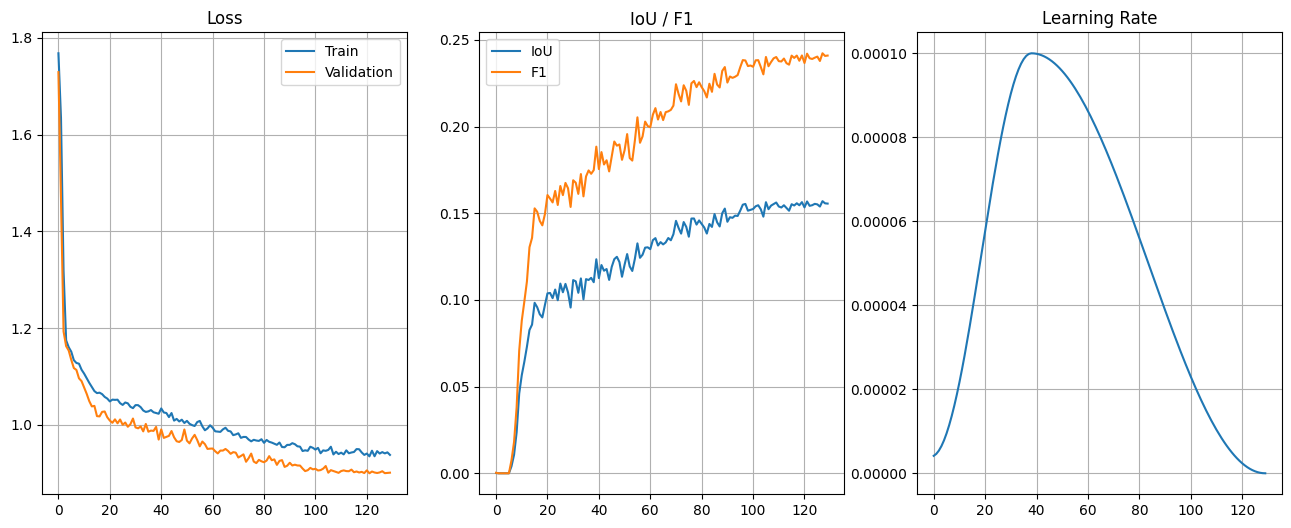


 Training Finished! | Best & Last saved in: /content/drive/MyDrive/ISPRS-Main/TRAIN_RESULTS


In [8]:
# ============================
# Section 24) Project header and imports
# ============================
# UT-FORMER (Multi-Scale) — FINAL CODE V-2025
# Patch=128 | in_channels=16 | Dropout2d=0.10
# Strong Augment | OneCycleLR (lr_init=3e-5, max_lr=1e-4)
# SAVE BEST + SAVE LAST → Drive

import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from einops import rearrange
import albumentations as A
import matplotlib.pyplot as plt
from tqdm import tqdm
import timm
from sklearn.model_selection import train_test_split
from skimage.morphology import remove_small_objects, binary_opening, disk


# ============================
# Section 25) Training configuration
# ============================
# Device selection
device = "cuda" if torch.cuda.is_available() else "cpu"

# Paths for patches and training outputs
PATCH_ROOT = "/content/drive/MyDrive/ISPRS-Main/PATCHES"
SAVE_DIR   = "/content/drive/MyDrive/ISPRS-Main/TRAIN_RESULTS"
os.makedirs(SAVE_DIR, exist_ok=True)

# Fixed post-processing and loss-related parameters
FIXED_TH       = 0.50
FIXED_MIN_SIZE = 20
POS_WEIGHT_VAL = 5.0

# Scheduler and training hyperparameters
INIT_LR  = 3e-5
MAX_LR   = 1e-4
EPOCHS   = 130
BATCH_SZ = 4


# ============================
# Section 26) Transformer block
# ============================
class TransformerBlock(nn.Module):
    def __init__(self, dim, heads=8, dropout=0.1):
        super().__init__()
        self.attn = nn.MultiheadAttention(dim, heads, dropout=dropout)
        self.ff = nn.Sequential(
            nn.Linear(dim, dim*4),
            nn.GELU(),
            nn.Linear(dim*4, dim)
        )
        self.norm1 = nn.LayerNorm(dim)
        self.norm2 = nn.LayerNorm(dim)

    def forward(self, x):
        # Self-attention and residual + norm
        attn, _ = self.attn(x, x, x)
        x = self.norm1(x + attn)
        # Feed-forward and residual + norm
        ff = self.ff(x)
        return self.norm2(x + ff)


# ============================
# Section 27) UT-Former with Dropout2d
# ============================
class UTFormer(nn.Module):
    def __init__(self, in_channels=16, dropout_dec=0.1):
        super().__init__()
        # Encoder backbone (ResNet34) with custom input channels
        self.encoder = timm.create_model("resnet34", pretrained=False)
        self.encoder.conv1 = nn.Conv2d(in_channels, 64, 7, 2, 3)

        # Transformer blocks at multiple scales
        self.tf128 = TransformerBlock(128)
        self.tf256 = TransformerBlock(256)
        self.tf512 = TransformerBlock(512)

        # Decoder upsampling path
        self.up1 = nn.ConvTranspose2d(512, 256, 2, 2)
        self.up2 = nn.ConvTranspose2d(256, 128, 2, 2)
        self.up3 = nn.ConvTranspose2d(128, 64, 2, 2)
        self.up4 = nn.ConvTranspose2d(64, 32, 2, 2)

        # Regularization in decoder
        self.dec_drop = nn.Dropout2d(dropout_dec)

        # Final 1-channel logit
        self.final = nn.Conv2d(32, 1, 1)

    def extract(self, x):
        """Extract multi-scale features from the encoder."""
        x = self.encoder.conv1(x)
        x = self.encoder.bn1(x)
        x = F.relu(x)
        x = self.encoder.maxpool(x)
        f1 = self.encoder.layer1(x)
        f2 = self.encoder.layer2(f1)
        f3 = self.encoder.layer3(f2)
        f4 = self.encoder.layer4(f3)
        return f2, f3, f4

    def tf(self, feat, block):
        """Apply transformer block on flattened spatial tokens and reshape back."""
        B, C, H, W = feat.shape
        x = rearrange(feat, "b c h w -> (h w) b c")
        x = block(x)
        return rearrange(x, "(h w) b c -> b c h w", h=H, w=W)

    def forward(self, x1, x2):
        # Extract features for both time steps
        f2a, f3a, f4a = self.extract(x1)
        f2b, f3b, f4b = self.extract(x2)

        # Multi-scale differences processed by transformer blocks
        d2 = self.tf(abs(f2a - f2b), self.tf128)
        d3 = self.tf(abs(f3a - f3b), self.tf256)
        d4 = self.tf(abs(f4a - f4b), self.tf512)

        # Decode with skip connections and dropout regularization
        up = self.dec_drop(F.relu(self.up1(d4)))
        up = self.dec_drop(F.relu(self.up2(up + d3)))
        up = self.dec_drop(F.relu(self.up3(up + d2)))
        up = self.dec_drop(F.relu(self.up4(up)))

        # Final logits and upsample to input size
        out = self.final(up)
        return F.interpolate(out, size=x1.shape[-2:], mode="bilinear")


# ============================
# Section 28) Dataset with strong augmentation
# ============================
class ChangeDetectionDataset(Dataset):
    def __init__(self, root, ids, augment=False):
        self.root    = root
        self.ids     = ids
        self.augment = augment

        # Strong augmentation pipeline for training
        self.train_transform = A.Compose([
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),
            A.RandomRotate90(p=0.5),
            A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=0.5),
            A.RandomBrightnessContrast(p=0.6),
            A.GaussianBlur(p=0.3),
            A.GaussNoise(p=0.3),
            A.CoarseDropout(max_holes=4, max_height=32, max_width=32, p=0.2),
        ], additional_targets={"image2": "image", "mask": "mask"})

        # Validation transform (no augmentation)
        self.val_transform = A.Compose([], additional_targets={"image2": "image", "mask": "mask"})

    def fix_channels(self, x):
        """Ensure tensor has exactly 16 channels (pad or trim if needed)."""
        if x.shape[0] > 16:
            return x[:16]
        if x.shape[0] < 16:
            return np.concatenate([x, np.zeros((16-x.shape[0],*x.shape[1:]))], 0)
        return x

    def __getitem__(self, idx):
        """Load and preprocess one sample (X1, X2, Y)."""
        pid = self.ids[idx]

        # Load patches
        X1 = np.load(f"{self.root}/X1/{pid}.npy")
        X2 = np.load(f"{self.root}/X2/{pid}.npy")
        Y  = np.load(f"{self.root}/Y/{pid}.npy")

        # Fix channels and normalize
        X1 = self.fix_channels(X1).astype(np.float32)/65535.0
        X2 = self.fix_channels(X2).astype(np.float32)/65535.0

        # Change shape from [C,H,W] → [H,W,C]
        X1, X2, Y = [np.moveaxis(z, 0, -1) for z in [X1, X2, Y]]

        # Apply augmentations
        if self.augment:
            out = self.train_transform(image=X1, image2=X2, mask=Y)
        else:
            out = self.val_transform(image=X1, image2=X2, mask=Y)

        X1, X2, Y = out["image"], out["image2"], out["mask"]

        # Convert back to [C,H,W]
        X1 = np.moveaxis(X1, -1, 0)
        X2 = np.moveaxis(X2, -1, 0)
        Y  = np.moveaxis(Y , -1, 0)

        return torch.tensor(X1), torch.tensor(X2), torch.tensor(Y)

    def __len__(self):
        return len(self.ids)


# ============================
# Section 29) Loss functions
# ============================
class DiceLoss(nn.Module):
    def forward(self, pred, t):
        """Dice loss for binary segmentation."""
        p   = torch.sigmoid(pred)
        num = 2*(p*t).sum()
        den = p.sum() + t.sum()
        return 1 - (num+1e-6)/(den+1e-6)

class FocalLoss(nn.Module):
    def __init__(self, gamma=2):
        super().__init__()
        self.gamma = gamma
    def forward(self, pred, t):
        """Focal loss to handle class imbalance."""
        p   = torch.sigmoid(pred)
        bce = F.binary_cross_entropy(p, t, reduction="none")
        pt  = p*t + (1-p)*(1-t)
        return ((1-pt)**self.gamma * bce).mean()

# Weighted BCE loss
pos_w = torch.tensor([POS_WEIGHT_VAL]).to(device)
bce   = nn.BCEWithLogitsLoss(pos_weight=pos_w)

# Instantiate losses
dice  = DiceLoss()
focal = FocalLoss()

# Combined loss function
def loss_fn(pred, t):
    return bce(pred, t) + dice(pred, t) + 0.5*focal(pred, t)


# ============================
# Section 30) Metrics
# ============================
def compute_metrics(pred, gt):
    """Compute IoU and F1 score for binary predictions."""
    pred = pred.view(-1)
    gt   = gt.view(-1)

    # True positives, false positives, false negatives
    TP = ((pred == 1) & (gt == 1)).sum().item()
    FP = ((pred == 1) & (gt == 0)).sum().item()
    FN = ((pred == 0) & (gt == 1)).sum().item()

    # Intersection over Union
    IoU = TP / (TP + FP + FN + 1e-6)

    # Precision and Recall
    prec = TP / (TP + FP + 1e-6)
    rec  = TP / (TP + FN + 1e-6)

    # F1 score
    F1 = 2 * (prec * rec) / (prec + rec + 1e-6)

    return IoU, F1


# ============================
# Section 31) Load dataset and create DataLoaders
# ============================
# Collect all patch IDs
ids = [f.replace(".npy", "") for f in os.listdir(f"{PATCH_ROOT}/X1")]

# Train/Validation split
train_ids, val_ids = train_test_split(ids, test_size=0.2, random_state=42)

# Build datasets
train_set = ChangeDetectionDataset(PATCH_ROOT, train_ids, augment=True)
val_set   = ChangeDetectionDataset(PATCH_ROOT, val_ids, augment=False)

# Create DataLoaders
train_loader = DataLoader(train_set, batch_size=BATCH_SZ, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SZ, shuffle=False, num_workers=2)


# ============================
# Section 32) Training with SAVE BEST + SAVE LAST
# ============================
model = UTFormer(in_channels=16, dropout_dec=0.1).to(device)

# Optimizer
opt = torch.optim.AdamW(model.parameters(), lr=INIT_LR, weight_decay=1e-4)

# OneCycleLR scheduler
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    opt, max_lr=MAX_LR, steps_per_epoch=len(train_loader), epochs=EPOCHS
)

# Tracking variables
best_loss   = 999
history_tr  = []
history_val = []
history_iou = []
history_f1  = []
history_lr  = []


def validate_onecycle():
    """Validation loop with IoU and F1 computation."""
    model.eval()
    L = I = F1t = 0
    with torch.no_grad():
        for X1, X2, Y in val_loader:
            X1, X2, Y = X1.to(device).float(), X2.to(device).float(), Y.to(device).float()
            pred = model(X1, X2)
            L   += loss_fn(pred, Y).item()
            binp = (torch.sigmoid(pred) > FIXED_TH).int().cpu()
            i, f = compute_metrics(binp, Y.cpu().int())
            I += i
            F1t += f
    n = len(val_loader)
    return L/n, I/n, F1t/n


print(" Training started with OneCycleLR…")

for ep in range(1, EPOCHS+1):
    model.train()
    tot = 0
    for X1, X2, Y in tqdm(train_loader):
        X1, X2, Y = X1.to(device).float(), X2.to(device).float(), Y.to(device).float()

        opt.zero_grad()
        pred = model(X1, X2)
        loss = loss_fn(pred, Y)
        loss.backward()
        opt.step()
        scheduler.step()

        tot += loss.item()

    # Training and validation metrics
    tr = tot / len(train_loader)
    vl, iou, f1 = validate_onecycle()

    history_tr.append(tr)
    history_val.append(vl)
    history_iou.append(iou)
    history_f1.append(f1)
    history_lr.append(opt.param_groups[0]["lr"])

    print(f"Epoch {ep:03d} | LR={opt.param_groups[0]['lr']:.6f} "
          f"| TrainLoss={tr:.4f} | ValLoss={vl:.4f} "
          f"| IoU={iou:.4f} | F1={f1:.4f}")

    # ---------------- SAVE BEST ----------------
    if vl < best_loss:
        best_loss = vl
        torch.save(model.state_dict(), f"{SAVE_DIR}/best_model.pth")
        print(" BEST MODEL SAVED")

    # ---------------- SAVE LAST ----------------
    torch.save(model.state_dict(), f"{SAVE_DIR}/last_model.pth")


# ============================
# Section 33) Training curves visualization
# ============================
plt.figure(figsize=(16,6))

# Loss curves
plt.subplot(1,3,1)
plt.title("Loss")
plt.plot(history_tr, label="Train")
plt.plot(history_val, label="Validation")
plt.legend()
plt.grid()

# IoU and F1 curves
plt.subplot(1,3,2)
plt.title("IoU / F1")
plt.plot(history_iou, label="IoU")
plt.plot(history_f1, label="F1")
plt.legend()
plt.grid()

# Learning rate curve
plt.subplot(1,3,3)
plt.title("Learning Rate")
plt.plot(history_lr)
plt.grid()

plt.show()


# ============================
# Section 34) Clean mask post-processing
# ============================
def clean_mask(mask):
    """Remove small objects and apply morphological opening to clean prediction mask."""
    mask = remove_small_objects(mask.astype(bool), min_size=FIXED_MIN_SIZE)
    mask = binary_opening(mask, disk(3))
    return mask.astype(np.uint8)


# ============================
# Section 35) Visualization of sample prediction
# ============================
def visualize_sample(th=FIXED_TH):
    """Visualize one random validation sample with GT vs prediction."""
    import random
    pid = random.choice(val_ids)

    # Load sample patches
    X1 = np.load(f"{PATCH_ROOT}/X1/{pid}.npy")
    X2 = np.load(f"{PATCH_ROOT}/X2/{pid}.npy")
    Y  = np.load(f"{PATCH_ROOT}/Y/{pid}.npy")

    # Convert to tensors
    X1t = torch.tensor(X1).unsqueeze(0).float().to(device)
    X2t = torch.tensor(X2).unsqueeze(0).float().to(device)

    # Model inference
    with torch.no_grad():
        pred = model(X1t, X2t)

    # Binarize and clean prediction
    binp = (torch.sigmoid(pred) > th).cpu().numpy()[0, 0]
    binp = clean_mask(binp)

    # Plot results
    plt.figure(figsize=(16,4))
    plt.subplot(1,4,1); plt.imshow(np.moveaxis(X1[:3],0,-1)); plt.title("T1")
    plt.subplot(1,4,2); plt.imshow(np.moveaxis(X2[:3],0,-1)); plt.title("T2")
    plt.subplot(1,4,3); plt.imshow(Y[0], cmap="gray");         plt.title("GT")
    plt.subplot(1,4,4); plt.imshow(binp, cmap="gray");         plt.title("Pred")
    plt.show()


# ============================
# Section 36) Final message
# ============================
print("\n Training Finished! | Best & Last saved in:", SAVE_DIR)


TEST

In [10]:
# ============================
# Section 37) Import libraries and set test root
# ============================
import os
import numpy as np
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
from tqdm import tqdm

# Root directory for test dataset
TEST_ROOT = "/content/drive/My Drive/ISPRS-Main/Urban_CD_Test_Data"


# ============================
# Section 38) Helper functions
# ============================
def load_hr_reference(location_path):
    """Find HR TIFF for reference size."""
    hr_path = os.path.join(location_path, "SN7-RGB-HR")
    for f in os.listdir(hr_path):
        if f.endswith(".tif") and ("2018" in f or "2017" in f):
            return os.path.join(hr_path, f)
    raise FileNotFoundError("HR reference not found!")


def resample_to_hr(s2_band_path, ref_profile):
    """Resample Sentinel-2 band to HR resolution."""
    with rasterio.open(s2_band_path) as src:
        src_data = src.read(1)

        # Create destination array with HR dimensions
        dst_data = np.zeros((ref_profile["height"], ref_profile["width"]),
                            dtype=src_data.dtype)

        # Perform reprojection and resampling
        reproject(
            source=src_data,
            destination=dst_data,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=ref_profile["transform"],
            dst_crs=ref_profile["crs"],
            resampling=Resampling.bilinear
        )

    return dst_data


def process_sentinel_folder(s2_folder, hr_ref_path, out_path):
    """Resample all Sentinel bands and save as NumPy array."""
    with rasterio.open(hr_ref_path) as ref:
        hr_profile = ref.profile

    # Collect all band files
    band_files = sorted([
        f for f in os.listdir(s2_folder)
        if f.endswith(".tiff") or f.endswith(".tif")
    ])

    stacked = []
    for bf in band_files:
        band_path = os.path.join(s2_folder, bf)
        resampled = resample_to_hr(band_path, hr_profile)
        stacked.append(resampled)

    # Stack into single array [Bands, H, W]
    stacked = np.stack(stacked, axis=0)
    np.save(out_path, stacked)
    return stacked


# ============================
# Section 39) Process test dataset locations
# ============================
locations = sorted(os.listdir(TEST_ROOT))

for loc in tqdm(locations, desc="Resampling Sentinel TEST"):
    loc_path = os.path.join(TEST_ROOT, loc)

    # HR reference image
    hr_ref = load_hr_reference(loc_path)

    # Sentinel-2 folders
    s2_root = os.path.join(loc_path, "Sentinel-2 Images")
    s2_times = sorted(os.listdir(s2_root))

    # Paths for two time steps
    T1_path = os.path.join(s2_root, s2_times[0])
    T2_path = os.path.join(s2_root, s2_times[1])

    # Output paths
    out_T1 = os.path.join(loc_path, "sentinel_T1_4m.npy")
    out_T2 = os.path.join(loc_path, "sentinel_T2_4m.npy")

    # Process both time steps
    process_sentinel_folder(T1_path, hr_ref, out_T1)
    process_sentinel_folder(T2_path, hr_ref, out_T2)


# ============================
# Section 40) Final message
# ============================
print("Sentinel TEST dataset resampled successfully!")

Resampling Sentinel TEST: 100%|██████████| 8/8 [03:49<00:00, 28.74s/it]

Sentinel TEST dataset resampled successfully!


 Model loaded from: /content/drive/MyDrive/ISPRS-Main/TRAIN_RESULTS/best_model.pth

🔍 Processing: L15-0361E-1300N_1446_2989_13


100%|██████████| 64/64 [00:01<00:00, 61.45it/s]
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:366: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = writer(



 Pure forward time: 0.8395 sec
 Avg per patch: 0.013116 sec
✔ Saved: /content/drive/My Drive/ISPRS-Main/TEST_PRED_RESULTS/L15-0361E-1300N_1446_2989_13_prediction.tif


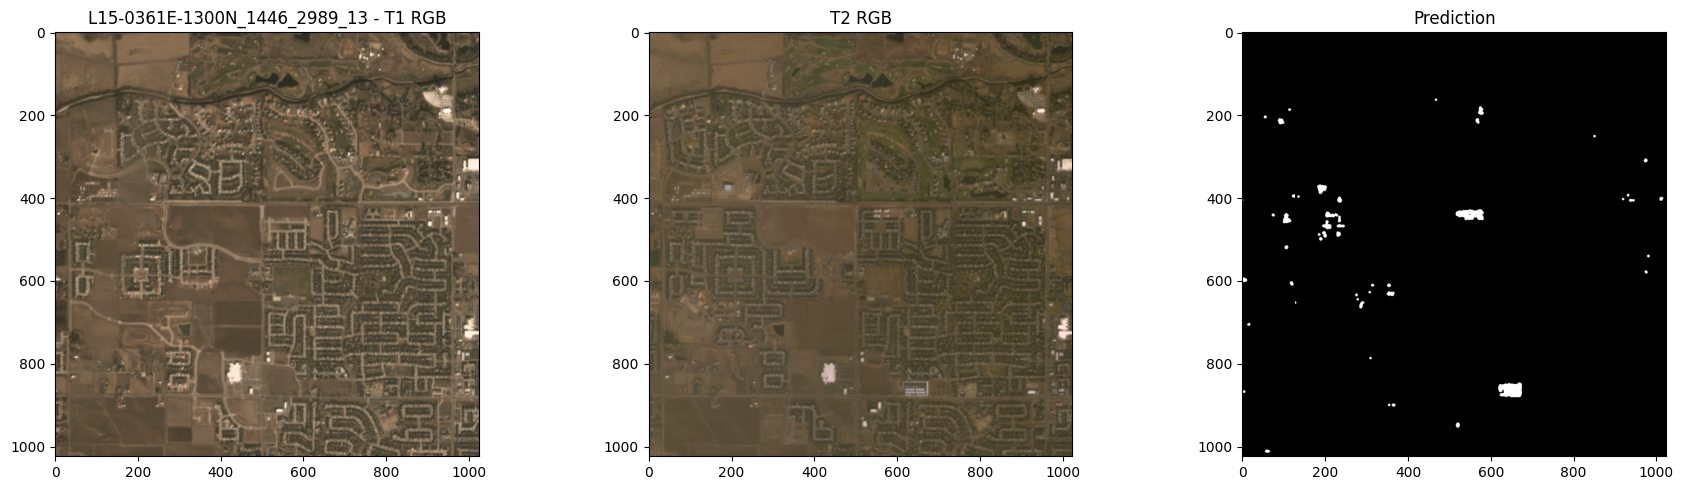


🔍 Processing: L15-0487E-1246N_1950_3207_13


100%|██████████| 64/64 [00:00<00:00, 64.68it/s]



 Pure forward time: 0.7905 sec
 Avg per patch: 0.012352 sec
✔ Saved: /content/drive/My Drive/ISPRS-Main/TEST_PRED_RESULTS/L15-0487E-1246N_1950_3207_13_prediction.tif


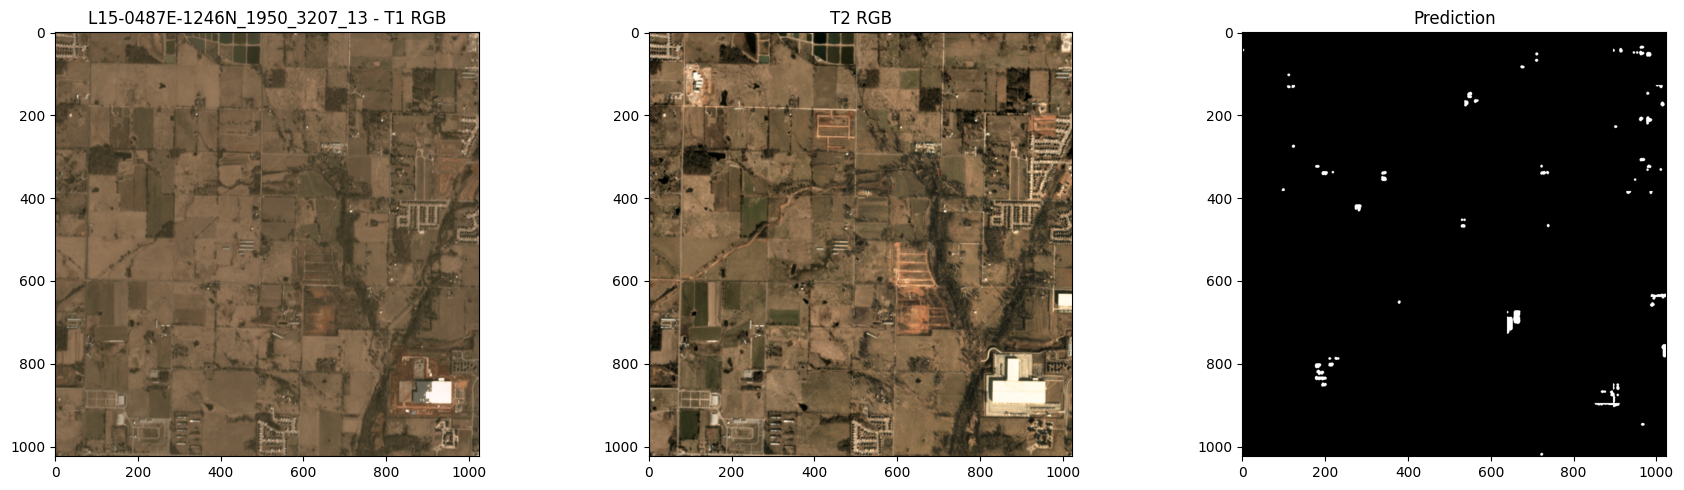


🔍 Processing: L15-0566E-1185N_2265_3451_13


100%|██████████| 64/64 [00:00<00:00, 64.94it/s]



 Pure forward time: 0.7882 sec
 Avg per patch: 0.012315 sec
✔ Saved: /content/drive/My Drive/ISPRS-Main/TEST_PRED_RESULTS/L15-0566E-1185N_2265_3451_13_prediction.tif


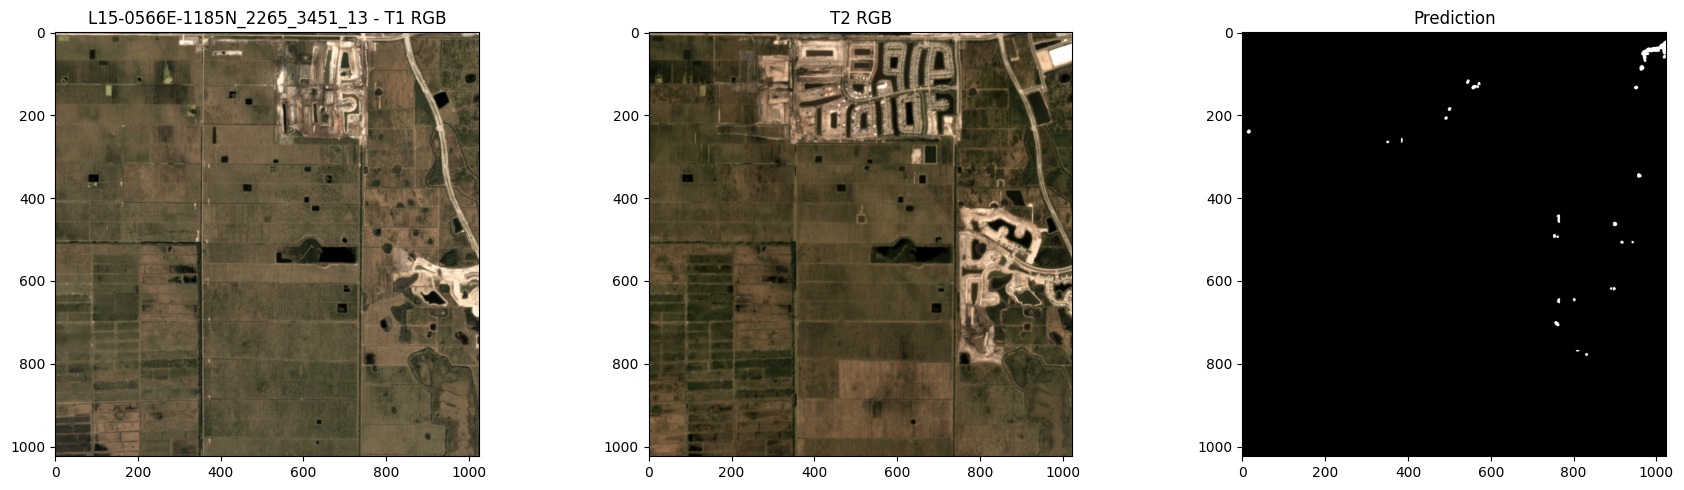


🔍 Processing: L15-1204E-1202N_4816_3380_13


100%|██████████| 64/64 [00:00<00:00, 64.18it/s]



 Pure forward time: 0.7928 sec
 Avg per patch: 0.012388 sec
✔ Saved: /content/drive/My Drive/ISPRS-Main/TEST_PRED_RESULTS/L15-1204E-1202N_4816_3380_13_prediction.tif


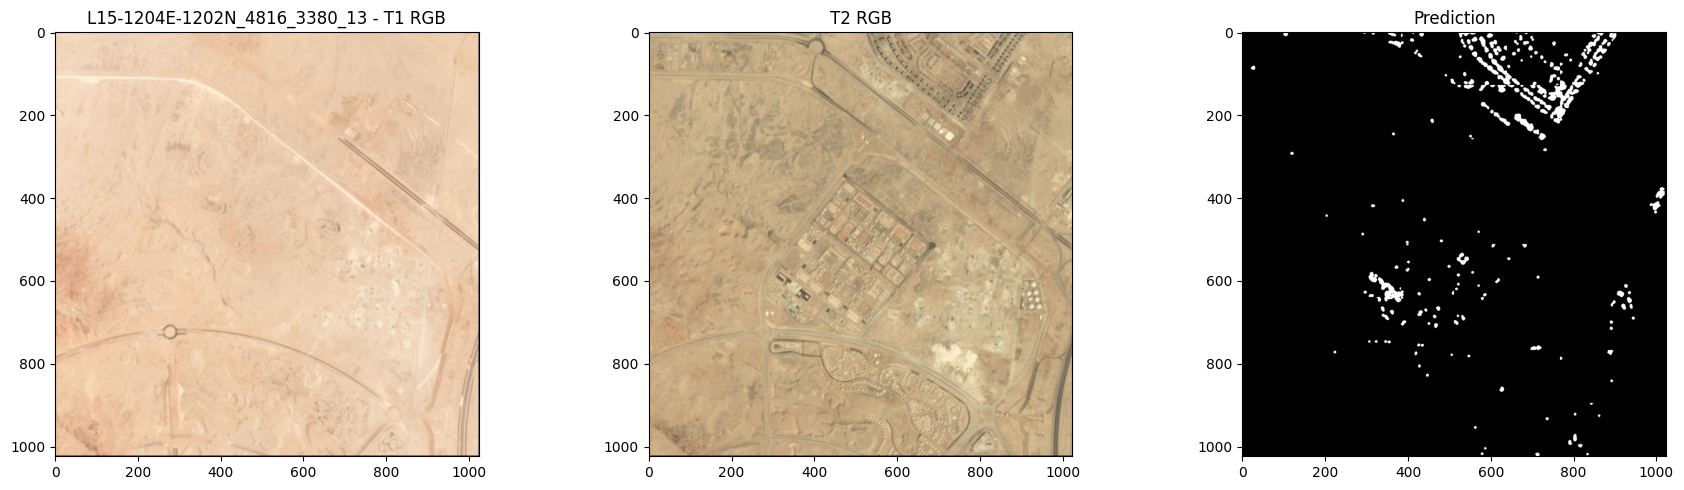


🔍 Processing: L15-1296E-1198N_5184_3399_13


100%|██████████| 64/64 [00:01<00:00, 62.79it/s]



 Pure forward time: 0.8106 sec
 Avg per patch: 0.012666 sec
✔ Saved: /content/drive/My Drive/ISPRS-Main/TEST_PRED_RESULTS/L15-1296E-1198N_5184_3399_13_prediction.tif


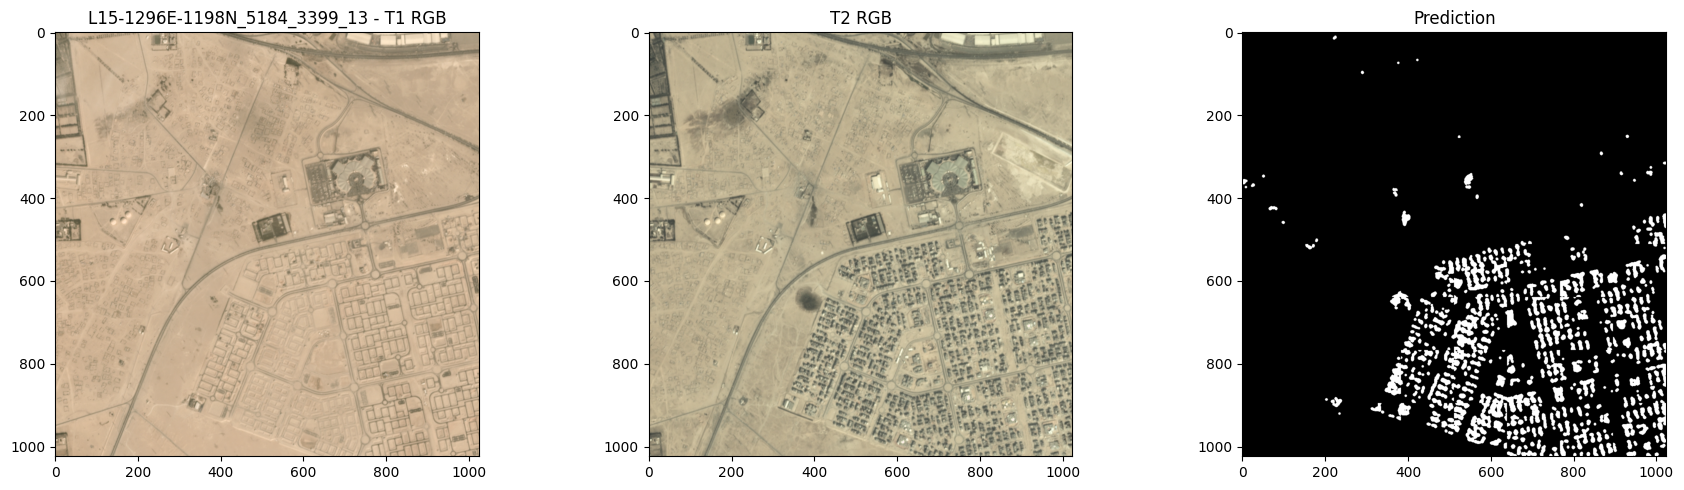


🔍 Processing: L15-1438E-1134N_5753_3655_13


100%|██████████| 64/64 [00:00<00:00, 64.27it/s]



 Pure forward time: 0.7935 sec
 Avg per patch: 0.012399 sec
✔ Saved: /content/drive/My Drive/ISPRS-Main/TEST_PRED_RESULTS/L15-1438E-1134N_5753_3655_13_prediction.tif


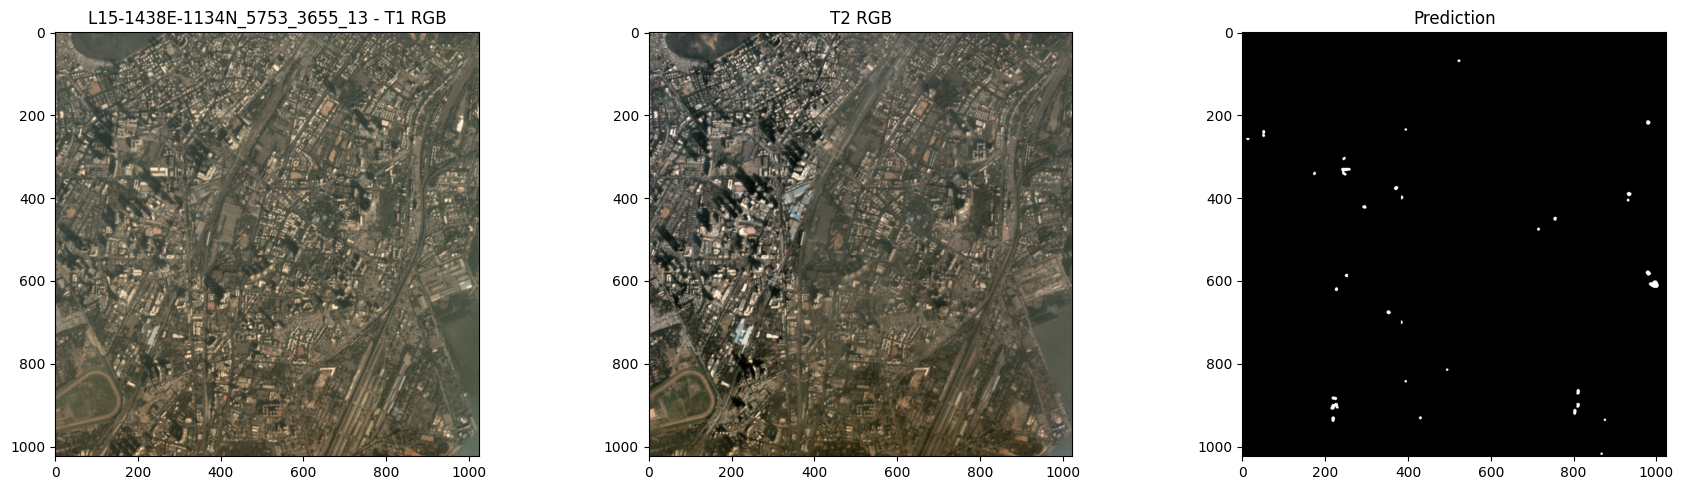


🔍 Processing: L15-1617E-1207N_6468_3360_13


100%|██████████| 56/56 [00:00<00:00, 64.88it/s]



 Pure forward time: 0.6868 sec
 Avg per patch: 0.012264 sec
✔ Saved: /content/drive/My Drive/ISPRS-Main/TEST_PRED_RESULTS/L15-1617E-1207N_6468_3360_13_prediction.tif


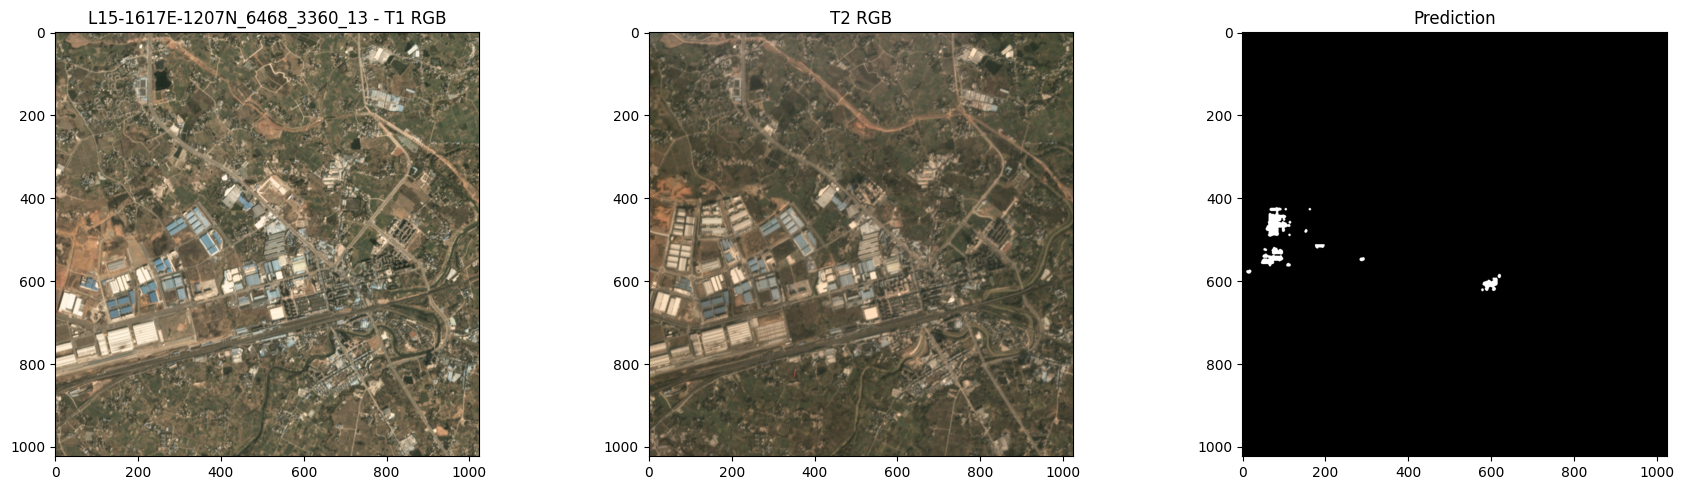


🔍 Processing: L15-1716E-1211N_6864_3345_13


100%|██████████| 64/64 [00:01<00:00, 62.16it/s]



 Pure forward time: 0.8154 sec
 Avg per patch: 0.012741 sec
✔ Saved: /content/drive/My Drive/ISPRS-Main/TEST_PRED_RESULTS/L15-1716E-1211N_6864_3345_13_prediction.tif


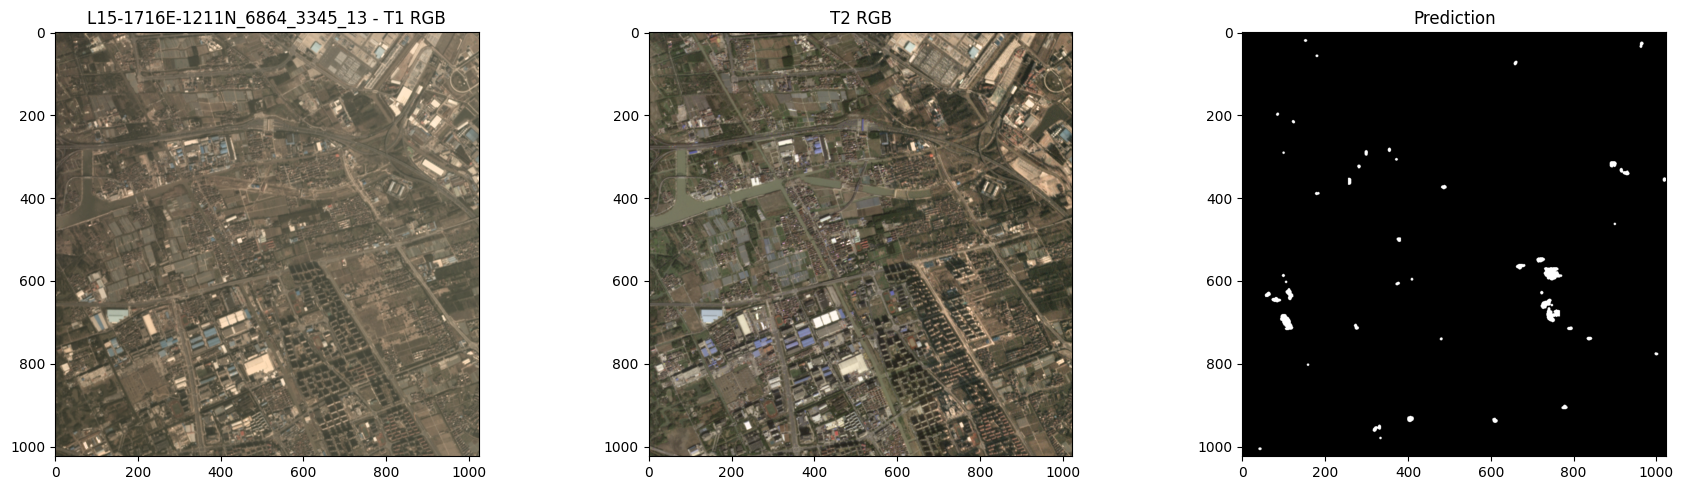


 All test locations processed + visualized!


In [11]:
# ============================
# Section 41) UT-Former — Test inference + forward time + visualization
# ============================
# Run inference on test dataset, measure pure forward time, and visualize predictions.

import os
import time
import numpy as np
import torch
import rasterio
from tqdm import tqdm
import matplotlib.pyplot as plt
from skimage.morphology import remove_small_objects, binary_opening, disk

# Device setup
device = "cuda" if torch.cuda.is_available() else "cpu"

# ============================
# Section 42) Paths and constants
# ============================
TEST_ROOT  = "/content/drive/My Drive/ISPRS-Main/Urban_CD_Test_Data"
SAVE_OUT   = "/content/drive/My Drive/ISPRS-Main/TEST_PRED_RESULTS"
MODEL_PATH = "/content/drive/MyDrive/ISPRS-Main/TRAIN_RESULTS/best_model.pth"

os.makedirs(SAVE_OUT, exist_ok=True)

PATCH    = 128
TH       = 0.50
MIN_SIZE = 20


# ============================
# Section 43) Clean mask function
# ============================
def clean_mask(mask):
    """Remove small objects and apply morphological opening to clean prediction mask."""
    mask = remove_small_objects(mask.astype(bool), min_size=MIN_SIZE)
    mask = binary_opening(mask, disk(3))
    return mask.astype(np.uint8)


# ============================
# Section 44) Patchify function
# ============================
def patchify(img, patch=128):
    """Divide image tensor into non-overlapping patches."""
    C, H, W = img.shape
    patches = []
    coords  = []

    for y in range(0, H - patch + 1, patch):
        for x in range(0, W - patch + 1, patch):
            patches.append(img[:, y:y+patch, x:x+patch])
            coords.append((y, x))
    return patches, coords, H, W


# ============================
# Section 45) Stitch function
# ============================
def stitch(patches, coords, H, W, patch=128):
    """Reconstruct full image from patches."""
    out = np.zeros((H, W), dtype=np.uint8)
    for idx, (y, x) in enumerate(coords):
        out[y:y+patch, x:x+patch] = patches[idx]
    return out


# ============================
# Section 46) Load trained model
# ============================
model = UTFormer(in_channels=16, dropout_dec=0.1).to(device)
model.load_state_dict(torch.load(MODEL_PATH))
model.eval()

print(" Model loaded from:", MODEL_PATH)


# ============================
# Section 47) Run inference on each test location
# ============================
locations = sorted(os.listdir(TEST_ROOT))

for loc in locations:
    print("\n==============================================")
    print("🔍 Processing:", loc)
    print("==============================================")

    loc_path = f"{TEST_ROOT}/{loc}"
    hr_path  = f"{loc_path}/SN7-RGB-HR"

    # Load HR images
    hr_files = sorted([f for f in os.listdir(hr_path) if f.endswith(".tif")])
    T1_hr = rasterio.open(f"{hr_path}/{hr_files[0]}").read()
    T2_hr = rasterio.open(f"{hr_path}/{hr_files[1]}").read()

    # Load Sentinel stacks
    S1 = np.load(f"{loc_path}/sentinel_T1_4m.npy")
    S2 = np.load(f"{loc_path}/sentinel_T2_4m.npy")

    # Build tensors
    X1 = np.concatenate([T1_hr, S1], axis=0).astype(np.float32) / 65535.0
    X2 = np.concatenate([T2_hr, S2], axis=0).astype(np.float32) / 65535.0

    # Patchify
    patches_X1, coords, H, W = patchify(X1, PATCH)
    patches_X2, _, _, _      = patchify(X2, PATCH)

    preds = []
    total_forward_time = 0.0

    # Inference per patch
    for p1, p2 in tqdm(zip(patches_X1, patches_X2), total=len(patches_X1)):
        t1 = torch.tensor(p1).unsqueeze(0).to(device)
        t2 = torch.tensor(p2).unsqueeze(0).to(device)

        # Forward timing
        torch.cuda.synchronize()
        start_t = time.time()

        with torch.no_grad():
            pr = model(t1, t2)

        torch.cuda.synchronize()
        end_t = time.time()
        total_forward_time += (end_t - start_t)

        pr = (torch.sigmoid(pr) > TH).cpu().numpy()[0, 0]
        pr = clean_mask(pr)
        preds.append(pr)

    print(f"\n Pure forward time: {total_forward_time:.4f} sec")
    print(f" Avg per patch: {total_forward_time/len(patches_X1):.6f} sec")

    # Stitch full image
    full_pred = stitch(preds, coords, H, W, PATCH)

    # Save prediction TIFF
    out_path = f"{SAVE_OUT}/{loc}_prediction.tif"
    with rasterio.open(
        out_path,
        "w",
        driver="GTiff",
        height=H,
        width=W,
        count=1,
        dtype="uint8"
    ) as dst:
        dst.write(full_pred, 1)

    print("✔ Saved:", out_path)

    # Visualization (RGB T1 - RGB T2 - Prediction)
    plt.figure(figsize=(18, 5))

    plt.subplot(1, 3, 1)
    plt.title(f"{loc} - T1 RGB")
    plt.imshow(np.moveaxis(T1_hr[:3], 0, -1))

    plt.subplot(1, 3, 2)
    plt.title("T2 RGB")
    plt.imshow(np.moveaxis(T2_hr[:3], 0, -1))

    plt.subplot(1, 3, 3)
    plt.title("Prediction")
    plt.imshow(full_pred, cmap="gray")

    plt.tight_layout()
    plt.show()


# ============================
# Section 48) Final message
# ============================
print("\n All test locations processed + visualized!")
